# 位置情報は緯度経度で距離感を加味したいな！
# validationデータの切り方も重要か？

★実行環境の選択

In [88]:
# VSCodeの場合
edi_flg = 1
# Googlre Colabの場合
# edi_flg = 0

In [89]:
if edi_flg == 0:
  # GoogleColabにGitHubリポジトリをクローンする用
  %cd /content/My_Python_project

  from google.colab import auth
  auth.authenticate_user()
  !git clone https://github.com/keiseki-eng/My_Python_project
  !git pull origin main



In [90]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [91]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold

# srcディレクトリをPythonの検索パスに追加
sys.path.append("/home/keiseki/JR_train_snow/30.src")

# validation.pyからsplit_timeを読み込み
from utils.validation import split_time

In [92]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

In [93]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [94]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../00.config/config.yaml')
  path_set = os.path.join('../00.config/path.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)
  with open(path_set, 'r') as f:
    path_config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/config.yaml"
  path_set = "My_Python_project/config/path.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)
  with open(path_set, "r") as f:
    path_config = yaml.safe_load(f)

In [95]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

# 気象データ分
locations = config["WEATHER_FEATURE"]["locations"]
variables = config["WEATHER_FEATURE"]["variables"]
hours = config["WEATHER_FEATURE"]["hours"]
w_categories = config["WEATHER_CATEGORY"]["WEATHER_CATEGORY_LIST"]

# 気象データの特徴量リストを作成
weather_feature_cols = [
    f"{location}_{variable}_{hour}"
    for location in locations
    for variable in variables
    for hour in hours
]
weather_categorical_cols = [
    f"{location}_{w_category}_{hour}"
    for location in locations
    for w_category in w_categories
    for hour in hours
]

# 積雪計データ分
snow_locations = config["SNOW_FEATURE"]["locations"]
snow_variables = config["SNOW_FEATURE"]["variables"]
snow_statistics = config["SNOW_FEATURE"]["statistics"]
snow_time_zones = config["SNOW_FEATURE"]["time_zones"]
snow_categories = config["SNOW_CATEGORY"]["SNOW_CATEGORY_LIST"]

# 積雪計データの特徴量リストを作成
snow_feature_cols = [
    f"{location}_{variable}_{statistic}_{time_zone}"
    for location in snow_locations
    for variable in snow_variables
    for statistic in snow_statistics
    for time_zone in snow_time_zones
]
snow_categorical_cols = [
    f"{location}_{snow_category}_{time_zone}"
    for location in snow_locations
    for snow_category in snow_categories
    for time_zone in snow_time_zones
]

# 通常の特徴量リストに気象データ分を追加
feature_list += weather_feature_cols
categorical_cols += weather_categorical_cols
# 通常の特徴量リストに積雪計データ分を追加
feature_list += snow_feature_cols
categorical_cols += snow_categorical_cols

In [96]:
# 学習データ、テストデータの読み込み
train_data_path = path_config['INTERIUM_PATH']['train_data']
test_data_path = path_config['INTERIUM_PATH']['test_data']

df_train = pd.read_pickle(train_data_path)
df_test = pd.read_pickle(test_data_path)

## addr1+2に対し、ターゲットエンコーディングを実装

In [97]:
# df_train, addr1_2_global_mean = target_encode_oof(
#     df_train,
#     col="addr1+2",
#     target="money_room",
#     n_splits=5,
#     smoothing=20
# )


## interaction特徴量を追加

## 05.train/valid 分割　＆　target加工

In [98]:
# feature_listに存在しないカラムがあれば、NaNで追加
fix_list = feature_list + ["年月日", "合計"]
df_train = df_train.reindex(columns=fix_list)
# 時系列分析のため、train_test_splitではなくsplit_timeを使用
X_train, X_valid, y_train, y_valid, = split_time(df_train, split_col="年月日", target_col="合計", split_date="2016-11-01")



train: 2016-01-19 00:00:00 ～ 2016-10-31 00:00:00
valid: 2016-11-01 00:00:00 ～ 2016-12-31 00:00:00
train件数: 12652
valid件数: 2687


In [99]:
print("train:")
print(X_train["年月日"].min(), "～", X_train["年月日"].max())

print("valid:")
print(X_valid["年月日"].min(), "～", X_valid["年月日"].max())

train:
2016-01-19 00:00:00 ～ 2016-10-31 00:00:00
valid:
2016-11-01 00:00:00 ～ 2016-12-31 00:00:00


## 07.モデル学習

In [ ]:
def wmae_eval(preds, train_data):
    y_true = train_data.get_label()

    # コンペ指定の重み
    weights = np.abs(y_true) * 1e4 + 1

    wmae = np.sum(weights * np.abs(y_true - preds)) / np.sum(weights)

    return "WMAE", wmae, False

In [101]:
# 学習データの前処理:特徴量リストに限定
X_train = X_train[feature_list].copy()
X_valid = X_valid[feature_list].copy()
    
# ：object型の列をcategoryへ
cat_cols = [c for c in categorical_cols if c in X_train.columns]
# 明示的にobject型の全列もcategoryに変換（未指定のカテゴリ列がある場合に備えて）
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

for df in [X_train, X_valid, df_test]:
    cols = sorted(set(cat_cols + obj_cols).intersection(df.columns))
    if cols:
        df[cols] = df[cols].astype("category")

/tmp/ipykernel_4588/4221972066.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [102]:
for col in [c for c in X_train.columns if "日照時間" in c]:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")


In [103]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)


# モデルの学習
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    feval=wmae_eval,
    callbacks=[
        lgb.early_stopping(100)
    ]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	training's rmse: 0.000971206	training's WMAE: 0.0156566	valid_1's rmse: 0.000149597	valid_1's WMAE: 0.0018331


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

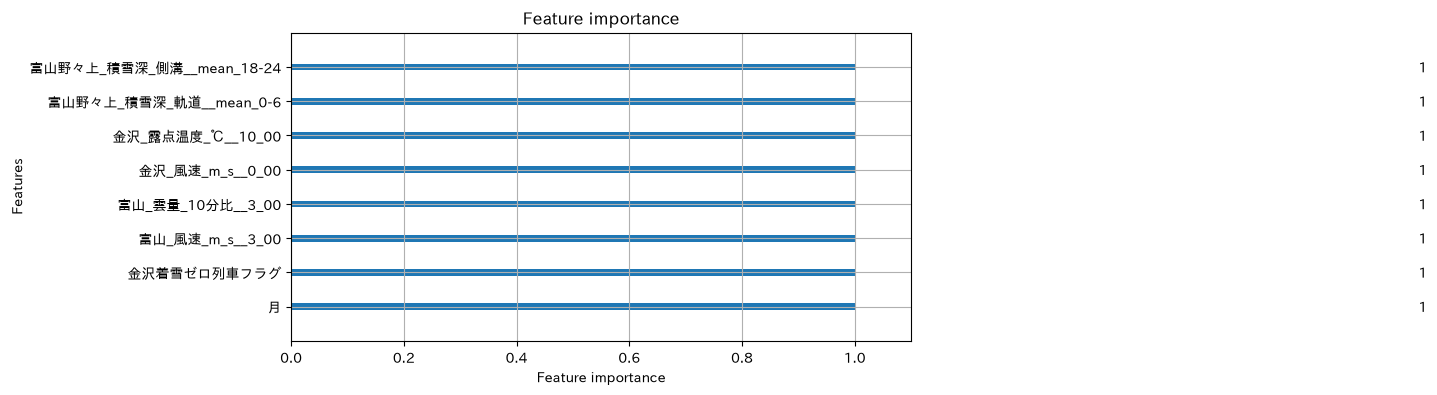

In [104]:
# 検証データで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [105]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [106]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [107]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


/home/keiseki/JR_train_snow/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


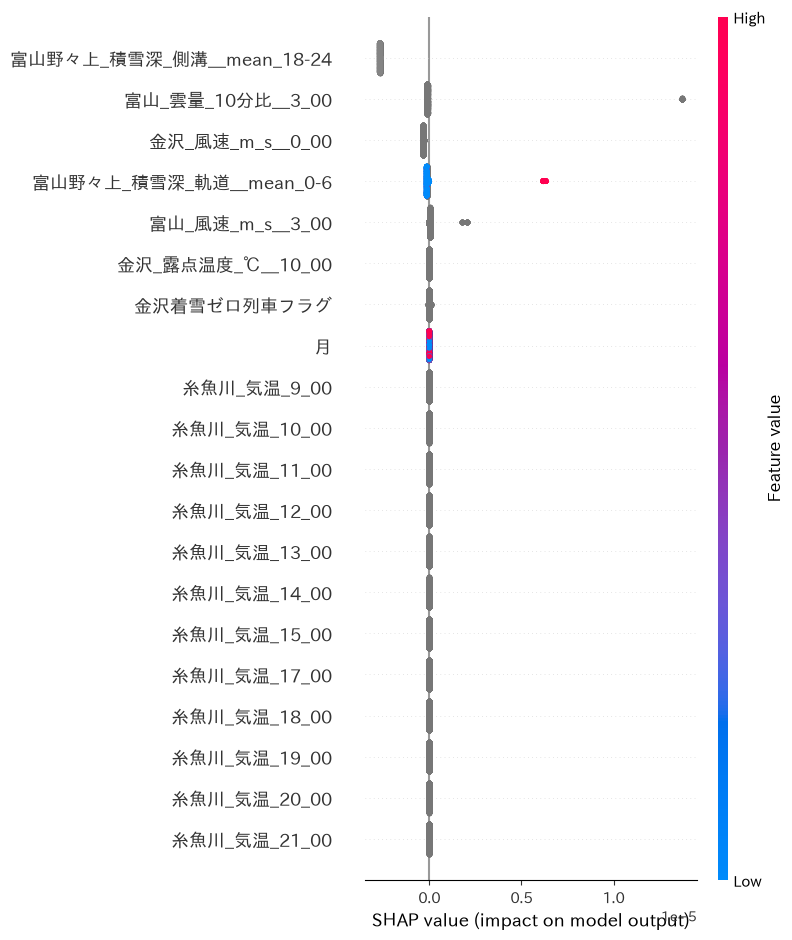

In [108]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

In [109]:
# 特徴量の選定
# feature_listに存在しないカラムがあれば、NaNで追加
df_test_p = df_test.reindex(columns=feature_list)

for col in [c for c in X_train.columns if "日照時間" in c]:
    df_test_p[col] = pd.to_numeric(df_test_p[col], errors="coerce")


# 予測
y_pred  = model.predict(df_test_p)
# y_scores_submit = np.clip(y_pred, 6e6, 1e8)

print(y_pred)

[5.72324505e-05 5.72324505e-05 5.72324505e-05 ... 5.72324505e-05
 5.72324505e-05 5.72324505e-05]


In [110]:

#提出用csvの作成
df_scores_submit = pd.DataFrame(y_pred)

# df_submit = pd.concat([df_test["id"], df_scores_submit], axis=1)
# df_scores_submit.index = df_scores_submit.index + 1
df_scores_submit.to_csv("submit.csv", index=True, header=False)




## 誤差要因分析

<Axes: ylabel='Frequency'>

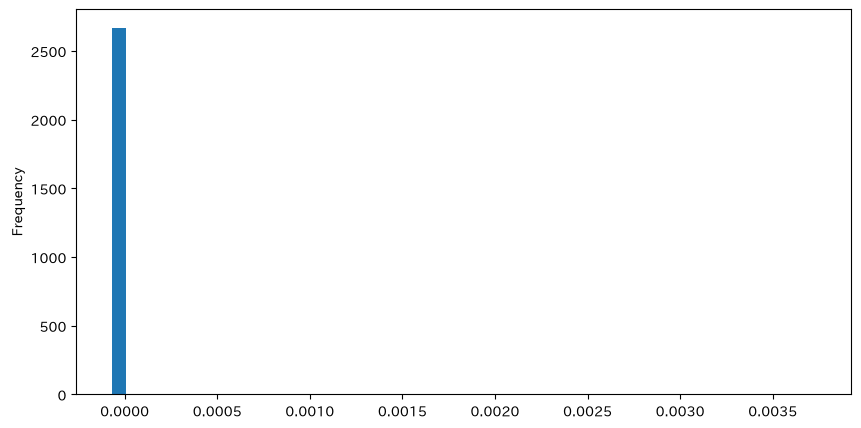

In [111]:
# valid予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
# 対数変換を戻す
# y_pred_valid = np.expm1(y_pred_valid)

df_eval = X_valid.copy()
df_eval["y_true"] = y_valid
df_eval["y_pred"] = y_pred_valid

# APE計算（0割防止）
df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# 上位ワースト確認
# df_eval.sort_values("ape", ascending=False).head(20)
df_eval["スコア差分"] = df_eval["y_true"] - df_eval["y_pred"]
df_eval["スコア差分"].plot.hist(bins=50, figsize=(10,5))

In [112]:
# # APEが大きい上位10%
# threshold = df_eval["ape"].quantile(0.9)
# bad_samples = df_eval[df_eval["ape"] >= threshold]

# # SHAP値抽出
# shap_values_valid = explainer.shap_values(X_valid)
# shap_df = pd.DataFrame(
#     shap_values_valid,
#     columns=X_valid.columns,
#     index=X_valid.index
# )


# # 悪いサンプルのSHAP平均
# shap_df.loc[bad_samples.index].abs().mean().sort_values(ascending=False).head(10)


In [113]:
# shap.force_plot(base_value=explainer.expected_value, shap_values=shap_values, features=X_train)

In [114]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# df_eval = X_valid.copy()
# df_eval["unit_area"] = np.expm1(df_eval["unit_area"])
# df_eval["y_true"] = y_valid
# df_eval["y_pred"] = y_pred_valid
# df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# # 上位10%の誤差サンプル抽出
# threshold = df_eval["ape"].quantile(0.9)
# bad_samples = df_eval[df_eval["ape"] >= threshold]

# # 調査対象の特徴量リスト
# check_features = [
#     "unit_area",
#     "post1",
#     "floor_plan_code",
#     "walk_distance1",
#     "walk_distance2",
# ]

# # タグ系カラムを抽出（feature_list に基づく）
# tag_features = [col for col in feature_list if col.startswith("tag_")]
# check_features.extend(tag_features)

# # 1. 数値特徴量の誤差 vs 値域の関係
# num_features = ["unit_area", "walk_distance1", "walk_distance2"]
# for col in num_features:
#     plt.figure(figsize=(8,4))
#     sns.scatterplot(data=df_eval, x=col, y="ape", alpha=0.3)
#     sns.scatterplot(data=bad_samples, x=col, y="ape", color="red", alpha=0.5)
#     plt.title(f"{col} と予測誤差(APE)の関係")
#     plt.ylabel("APE")
#     plt.xlabel(col)
#     plt.show()

# # 2. カテゴリ特徴量の誤差分布（箱ひげ図）
# cat_features = ["post1", "floor_plan_code"]
# for col in cat_features:
#     plt.figure(figsize=(10,4))
#     sns.boxplot(x=col, y="ape", data=df_eval)
#     plt.title(f"{col} ごとの予測誤差(APE)分布")
#     plt.xticks(rotation=45)
#     plt.show()

# # 3. タグ系特徴量の影響（悪いサンプルと全体比較）
# for col in tag_features:
#     if col not in df_eval.columns:
#         continue
#     mean_all = df_eval[col].mean()
#     mean_bad = bad_samples[col].mean()
#     print(f"{col}: 全体平均={mean_all:.3f}, 誤差上位10%平均={mean_bad:.3f}")
